### LSTM 

In [34]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import ast

In [35]:


HORIZON = 24
SEQ_LEN = 48
EPOCHS = 50


df_main = pd.read_csv("final_data.csv")
df_main["datetime"] = pd.to_datetime(df_main["datetime"])

dk = pd.read_csv("hourly_data_Danmark_55.99775695800781_10.0052490234375.csv")
ring = pd.read_csv("hourly_data_Ringsted_56.1740608215332_9.545852661132812.csv")
silk = pd.read_csv("hourly_data_Silkeborg_55.444580078125_11.78314208984375.csv")

for df in [dk, ring, silk]:
    df["date"] = pd.to_datetime(df["date"])

dk = dk.add_prefix("dk_").rename(columns={"dk_date": "datetime"})
ring = ring.add_prefix("ring_").rename(columns={"ring_date": "datetime"})
silk = silk.add_prefix("silk_").rename(columns={"silk_date": "datetime"})

df = df_main.merge(dk, on="datetime", how="left")
df = df.merge(ring, on="datetime", how="left")
df = df.merge(silk, on="datetime", how="left")

df = df.sort_values("datetime")
print("before", len(df))

df["hour"] = df["datetime"].dt.hour

df["lag_1"] = df["value_spot"].shift(1)
df["lag_2"] = df["value_spot"].shift(2)
df["lag_24"] = df["value_spot"].shift(24)

df = df.ffill()



df = pd.get_dummies(df, columns=[c for c in ["zone_prev", "zone"] if c in df.columns], drop_first=True)

# IMPORT
df["import"] = df["import"].apply(ast.literal_eval)
import_expanded = df["import"].apply(pd.Series).add_prefix("import_")

# EXPORT
df["export"] = df["export"].apply(ast.literal_eval)
export_expanded = df["export"].apply(pd.Series).add_prefix("export_")

# Combine everything
df = pd.concat(
    [df.drop(columns=["import", "export"]), import_expanded, export_expanded],
    axis=1
)



df["mix"] = df["mix"].apply(ast.literal_eval)
expanded = df["mix"].apply(pd.Series)
df = pd.concat([df.drop(columns=["mix"]), expanded], axis=1)



df = df.join(df["flows"].apply(pd.Series))

df = df.fillna(0)

df = df.drop(columns=["emissionFactorType", "battery storage", "hydro storage", "flows", "unit_spot", "unit_total_load"])




before 34994


/var/folders/xw/j6c1c3514_l7lyj6wyc6l1rc0000gn/T/ipykernel_21894/3005010109.py:63: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


In [36]:
df["value_spot"].describe()

count    34994.000000
mean       149.466225
std        128.188643
min       -440.100000
25%         70.080000
50%        112.870000
75%        193.722500
max        871.000000
Name: value_spot, dtype: float64

In [37]:
for i in range(1, HORIZON + 1):
    df[f"price_t+{i}"] = df["value_spot"].shift(-i)
    df[f"carbon_t+{i}"] = df["carbonIntensity"].shift(-i)

hours = df["hour"].values
df = df.drop(columns=["datetime"], errors="ignore")
df = df.dropna()

target_cols = (
    [f"price_t+{i}" for i in range(1, HORIZON + 1)] +
    [f"carbon_t+{i}" for i in range(1, HORIZON + 1)]
)

X = df.drop(columns=target_cols).values
Y = df[target_cols].values
hours = hours[-len(X):]


split1 = int(0.7 * len(X))
split2 = int(0.85 * len(X))

X_train, X_val, X_test = X[:split1], X[split1:split2], X[split2:]
Y_train, Y_val, Y_test = Y[:split1], Y[split1:split2], Y[split2:]
h_train, h_val, h_test = hours[:split1], hours[split1:split2], hours[split2:]


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

def create_sequences_12(X, Y, hours, seq_len=48):
    X_seq, Y_seq = [], []

    for i in range(len(X) - seq_len - HORIZON):
        if hours[i + seq_len - 1] != 12:
            continue

        X_seq.append(X[i:i+seq_len])
        Y_seq.append(Y[i+seq_len])

    return np.array(X_seq), np.array(Y_seq)

X_train, Y_train = create_sequences_12(X_train, Y_train, h_train, SEQ_LEN)
X_val, Y_val = create_sequences_12(X_val, Y_val, h_val, SEQ_LEN)
X_test, Y_test = create_sequences_12(X_test, Y_test, h_test, SEQ_LEN)

In [38]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, Y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, Y_val), batch_size=64)
test_loader  = DataLoader(SeqDataset(X_test, Y_test), batch_size=64)


class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 256, num_layers=5, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 48)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

model = LSTMModel(X_train.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [39]:
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for Xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            val_loss += criterion(model(Xb), yb).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train: {train_loss:.2f}, Val: {val_loss:.2f}")

model.eval()
preds, actuals = [], []

with torch.no_grad():
    for Xb, yb in test_loader:
        preds.append(model(Xb).numpy())
        actuals.append(yb.numpy())

preds = np.vstack(preds)
actuals = np.vstack(actuals)

price_pred = preds[:, :24]
carbon_pred = preds[:, 24:]

price_true = actuals[:, :24]
carbon_true = actuals[:, 24:]

print("\nFINAL RESULTS")
print(f"Price MAE: {np.mean(np.abs(price_pred - price_true)):.2f}")
print(f"Carbon MAE: {np.mean(np.abs(carbon_pred - carbon_true)):.2f}")


Epoch 1, Train: 659794.57, Val: 34541.75
Epoch 2, Train: 589597.61, Val: 20769.43
Epoch 3, Train: 427927.12, Val: 7531.11
Epoch 4, Train: 254154.64, Val: 20687.17
Epoch 5, Train: 190304.27, Val: 43870.37
Epoch 6, Train: 189765.64, Val: 40172.16
Epoch 7, Train: 186951.66, Val: 34131.36
Epoch 8, Train: 187389.35, Val: 34438.83
Epoch 9, Train: 187253.71, Val: 35520.47
Epoch 10, Train: 187127.45, Val: 35696.24
Epoch 11, Train: 187347.30, Val: 36113.65
Epoch 12, Train: 187117.83, Val: 34188.14
Epoch 13, Train: 187177.58, Val: 36215.17
Epoch 14, Train: 187373.35, Val: 34999.60
Epoch 15, Train: 187468.44, Val: 35784.23
Epoch 16, Train: 187152.29, Val: 35978.02
Epoch 17, Train: 187082.73, Val: 35158.96
Epoch 18, Train: 187335.82, Val: 34812.82
Epoch 19, Train: 187535.00, Val: 37357.27
Epoch 20, Train: 187652.20, Val: 32886.02
Epoch 21, Train: 186691.85, Val: 37261.55
Epoch 22, Train: 187090.30, Val: 36366.85
Epoch 23, Train: 187057.34, Val: 36461.51
Epoch 24, Train: 187024.59, Val: 34964.26
Ep

KeyboardInterrupt: 

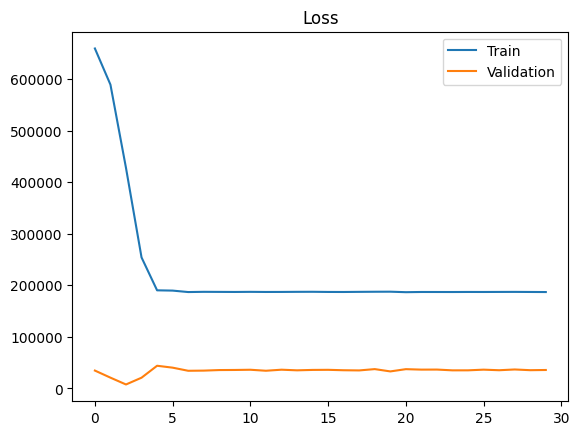

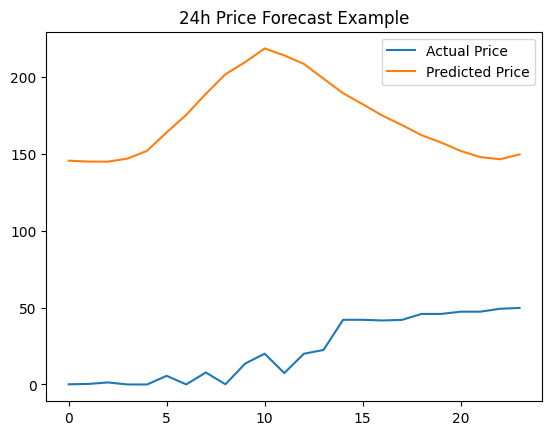

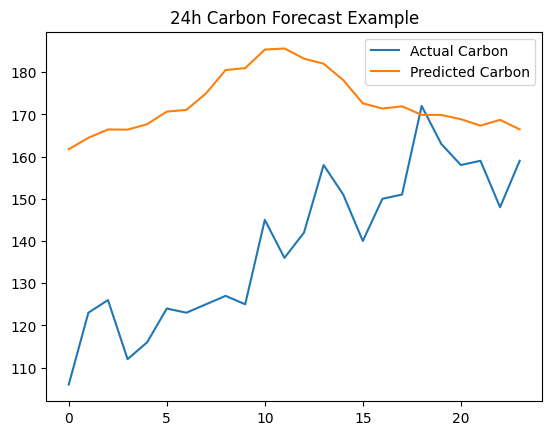

In [46]:
# Loss curves
plt.figure()
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()

#example plot
idx = 200

plt.figure()
plt.plot(price_true[idx], label="Actual Price")
plt.plot(price_pred[idx], label="Predicted Price")
plt.legend()
plt.title("24h Price Forecast Example")
plt.show()

plt.figure()
plt.plot(carbon_true[idx], label="Actual Carbon")
plt.plot(carbon_pred[idx], label="Predicted Carbon")
plt.legend()
plt.title("24h Carbon Forecast Example")
plt.show()